# Urban Accessibility Equity Scenarios

This case follows mature street-network accessibility workflows: graph construction, travel-time impedance, demand weighting, baseline gap diagnosis, scenario optimization, and sensitivity testing.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import Point
from IPython.display import display, Markdown
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print("Data files:", [p.name for p in sorted(DATA.iterdir())])

Data files: ['candidate_facilities.csv', 'edges.csv', 'facilities.csv', 'neighborhoods.geojson', 'nodes.csv']


In [2]:
nodes = pd.read_csv(DATA / "nodes.csv")
edges = pd.read_csv(DATA / "edges.csv")
facilities = pd.read_csv(DATA / "facilities.csv")
candidates = pd.read_csv(DATA / "candidate_facilities.csv")
zones = gpd.read_file(DATA / "neighborhoods.geojson")
display(nodes.head())
display(edges.head())
display(zones[["zone_id", "population", "low_income", "elderly", "car_free", "nearest_node"]].head())

,node,x,y,district
0,0,118.720002,32.000358,D1
1,1,118.737589,31.998931,D1
2,2,118.755318,31.998810,D1
3,3,118.774090,32.001608,D1
4,4,118.791262,31.999255,D1


,u,v,length_m,walk_min
0,0,1,1555.738326,21.313990
1,1,0,1555.738326,21.313990
2,0,9,1365.726949,20.149945
3,9,0,1365.726949,20.149945
4,1,2,1560.227718,17.718473


,zone_id,population,low_income,elderly,car_free,nearest_node
0,Z01,2227,0.410185,0.188812,0.517258,0
1,Z02,3956,0.433315,0.197239,0.289343,3
2,Z03,2849,0.247700,0.159839,0.319096,5
3,Z04,1316,0.376904,0.163712,0.320214,7
4,Z05,3748,0.391479,0.184344,0.379727,18


In [3]:
G = nx.DiGraph()
for row in nodes.itertuples(index=False):
    G.add_node(int(row.node), x=float(row.x), y=float(row.y), district=row.district)
for row in edges.itertuples(index=False):
    G.add_edge(int(row.u), int(row.v), length_m=float(row.length_m), walk_min=float(row.walk_min))
components = nx.number_weakly_connected_components(G)
total_length_km = edges["length_m"].sum() / 2 / 1000
print(f"Graph nodes={G.number_of_nodes()}, directed_edges={G.number_of_edges()}, weak_components={components}, undirected_length={total_length_km:.1f} km")

Graph nodes=72, directed_edges=254, weak_components=1, undirected_length=201.4 km


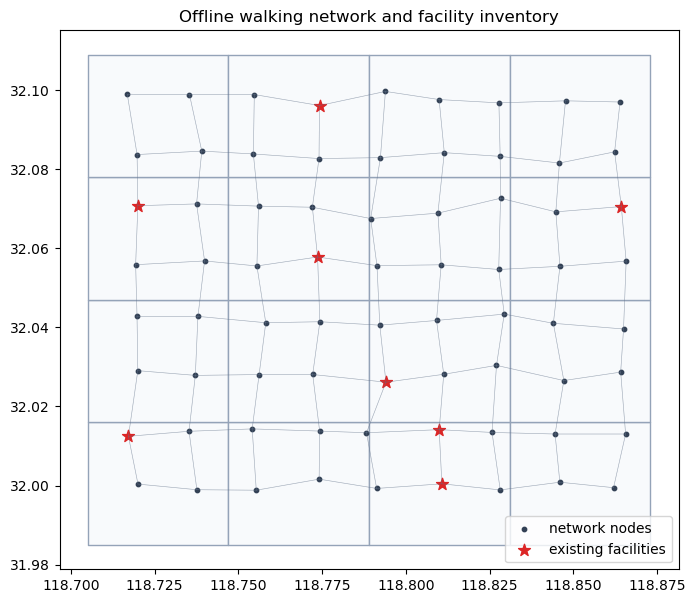

Saved outputs/network_inventory.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
zones.plot(ax=ax, color="#f8fafc", edgecolor="#94a3b8", linewidth=1)
for row in edges.itertuples(index=False):
    a = nodes.loc[nodes.node == row.u].iloc[0]
    b = nodes.loc[nodes.node == row.v].iloc[0]
    ax.plot([a.x, b.x], [a.y, b.y], color="#64748b", linewidth=0.4, alpha=0.35)
ax.scatter(nodes.x, nodes.y, s=10, color="#334155", label="network nodes")
fac_xy = facilities.merge(nodes, left_on="node", right_on="node")
ax.scatter(fac_xy.x, fac_xy.y, s=80, color="#dc2626", marker="*", label="existing facilities")
ax.set_title("Offline walking network and facility inventory")
ax.legend(loc="lower right")
fig.savefig(OUTPUTS / "network_inventory.png", dpi=170)
plt.show()
print("Saved outputs/network_inventory.png")

In [5]:
zones["vulnerability"] = (
    0.45 * zones["low_income"] + 0.30 * zones["car_free"] + 0.25 * zones["elderly"]
)
zones["weighted_demand"] = zones["population"] * (1 + zones["vulnerability"])
display(zones[["zone_id", "population", "vulnerability", "weighted_demand"]].sort_values("weighted_demand", ascending=False).head(8).round(2))

,zone_id,population,vulnerability,weighted_demand
10,Z11,4555,0.38,6273.04
14,Z15,4013,0.40,5602.83
9,Z10,4450,0.25,5552.31
5,Z06,4027,0.37,5524.06
7,Z08,4238,0.29,5485.22
1,Z02,3956,0.33,5265.85
4,Z05,3748,0.34,5007.96
11,Z12,3799,0.30,4952.55


In [6]:
facility_nodes = sorted(facilities["node"].unique())
dist_to_fac = {}
for zone in zones.itertuples():
    lengths = nx.single_source_dijkstra_path_length(G, int(zone.nearest_node), weight="walk_min")
    dist_to_fac[zone.zone_id] = min(lengths.get(int(node), np.inf) for node in facility_nodes)
zones["nearest_facility_min"] = zones["zone_id"].map(dist_to_fac)
zones["access_gap"] = np.maximum(0, zones["nearest_facility_min"] - 12)
zones["gap_score"] = zones["access_gap"] * zones["weighted_demand"]
display(zones[["zone_id", "nearest_facility_min", "access_gap", "gap_score"]].sort_values("gap_score", ascending=False).round(2))

,zone_id,nearest_facility_min,access_gap,gap_score
10,Z11,61.92,49.92,313170.06
7,Z08,55.73,43.73,239882.65
1,Z02,44.54,32.54,171371.02
14,Z15,40.96,28.96,162283.93
11,Z12,43.05,31.05,153776.47
12,Z13,46.44,34.44,115664.70
5,Z06,25.23,13.23,73069.29
8,Z09,27.11,15.11,71850.76
15,Z16,53.19,41.19,67260.95
3,Z04,44.18,32.18,55333.68


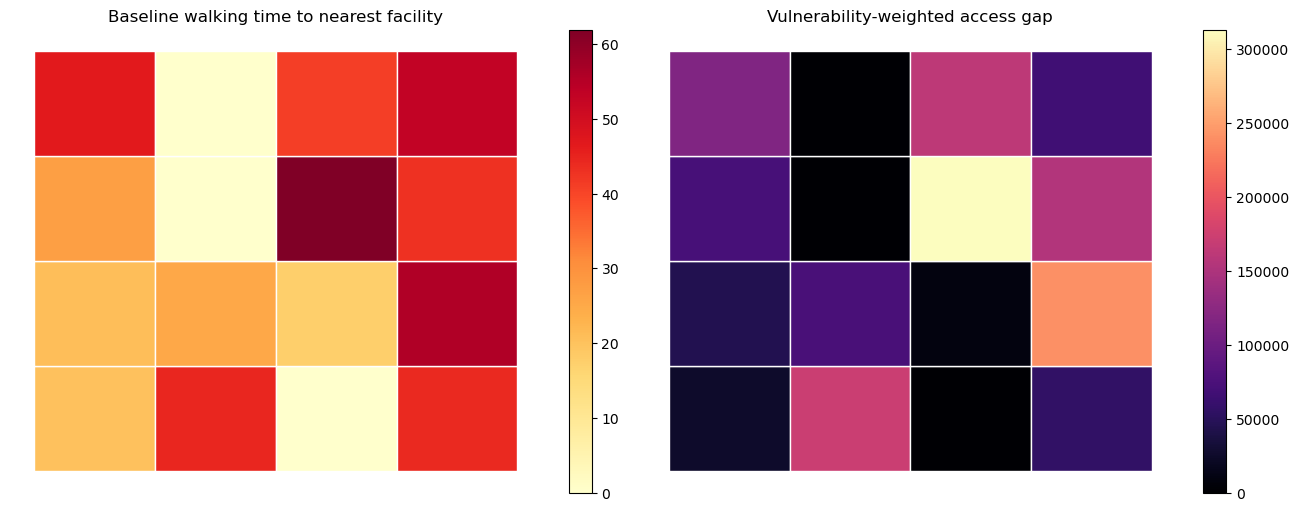

Saved outputs/baseline_access_gap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
zones.plot(column="nearest_facility_min", ax=axes[0], cmap="YlOrRd", legend=True, edgecolor="white")
axes[0].set_title("Baseline walking time to nearest facility")
zones.plot(column="gap_score", ax=axes[1], cmap="magma", legend=True, edgecolor="white")
axes[1].set_title("Vulnerability-weighted access gap")
for ax in axes:
    ax.set_axis_off()
fig.savefig(OUTPUTS / "baseline_access_gap.png", dpi=170)
plt.show()
print("Saved outputs/baseline_access_gap.png")

In [8]:
def evaluate_added_sites(site_nodes, threshold=12):
    active = sorted(set(facility_nodes) | set(site_nodes))
    minutes = []
    for zone in zones.itertuples():
        lengths = nx.single_source_dijkstra_path_length(G, int(zone.nearest_node), weight="walk_min")
        minutes.append(min(lengths.get(int(node), np.inf) for node in active))
    minutes = np.asarray(minutes)
    covered = minutes <= threshold
    vulnerable_covered = float(zones.loc[covered, "weighted_demand"].sum())
    gap_score = float((np.maximum(0, minutes - threshold) * zones["weighted_demand"].values).sum())
    return vulnerable_covered, gap_score, minutes

baseline_cov, baseline_gap, _ = evaluate_added_sites([])
rows = []
for cand in candidates.itertuples(index=False):
    cov, gap, _ = evaluate_added_sites([int(cand.node)])
    rows.append({"candidate_id": cand.candidate_id, "node": int(cand.node), "added_covered_demand": cov - baseline_cov, "remaining_gap_score": gap})
candidate_scores = pd.DataFrame(rows).sort_values(["added_covered_demand", "remaining_gap_score"], ascending=[False, True])
display(candidate_scores.round(2))

,candidate_id,node,added_covered_demand,remaining_gap_score
2,C3,18,5007.96,1457934.36
9,C10,70,1633.13,1434935.71
5,C6,41,0.00,1224829.01
6,C7,49,0.00,1257671.15
4,C5,33,0.00,1351464.76
0,C1,2,0.00,1370885.74
3,C4,27,0.00,1448809.39
8,C9,62,0.00,1473240.27
1,C2,11,0.00,1487220.72
7,C8,57,0.00,1502196.66


In [9]:
selected = []
history = []
for step in range(3):
    best = None
    for cand in candidates.itertuples(index=False):
        if int(cand.node) in selected:
            continue
        cov, gap, minutes = evaluate_added_sites(selected + [int(cand.node)])
        score = cov - 0.001 * gap
        record = {"step": step + 1, "candidate_id": cand.candidate_id, "node": int(cand.node), "covered_demand": cov, "gap_score": gap, "score": score}
        if best is None or score > best["score"]:
            best = record
    selected.append(best["node"])
    history.append(best)
scenario = pd.DataFrame(history)
_, scenario_gap, scenario_minutes = evaluate_added_sites(selected)
zones["scenario_min"] = scenario_minutes
zones["scenario_improvement"] = zones["nearest_facility_min"] - zones["scenario_min"]
display(scenario.round(2))
print(f"Selected candidate nodes: {selected}")

,step,candidate_id,node,covered_demand,gap_score,score
0,1,C3,18,17535.24,1457934.36,16077.30
1,2,C10,70,19168.37,1390673.42,17777.69
2,3,C6,41,19168.37,1113305.76,18055.06


Selected candidate nodes: [18, 70, 41]


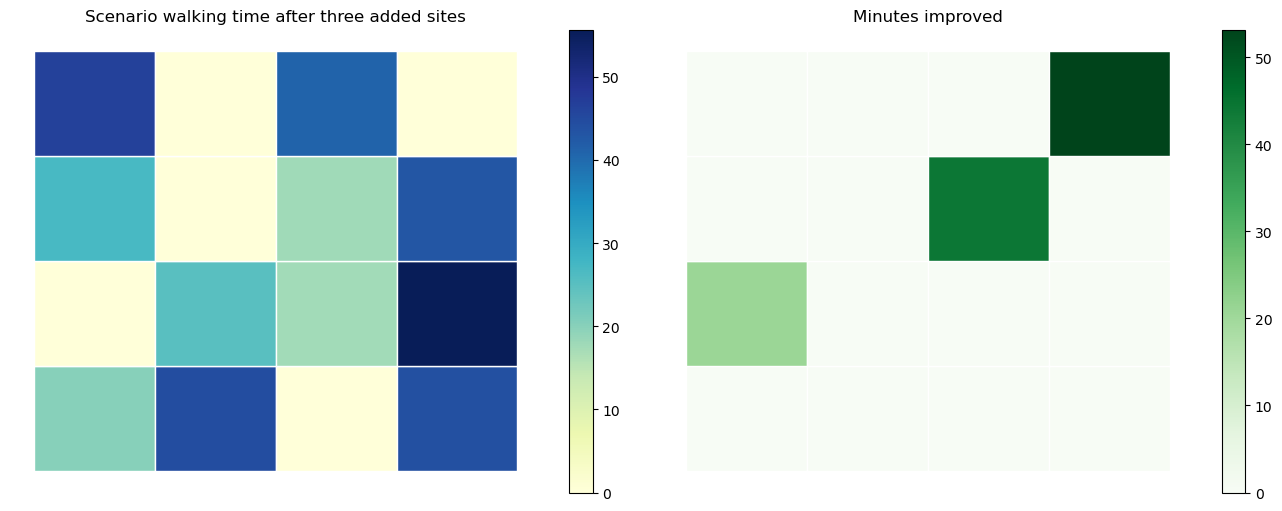

Saved outputs/scenario_access_improvement.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
zones.plot(column="scenario_min", ax=axes[0], cmap="YlGnBu", legend=True, edgecolor="white")
axes[0].set_title("Scenario walking time after three added sites")
zones.plot(column="scenario_improvement", ax=axes[1], cmap="Greens", legend=True, edgecolor="white")
axes[1].set_title("Minutes improved")
for ax in axes:
    ax.set_axis_off()
fig.savefig(OUTPUTS / "scenario_access_improvement.png", dpi=170)
plt.show()
print("Saved outputs/scenario_access_improvement.png")

In [11]:
district_summary = zones.assign(district=zones["zone_id"].str.slice(0, 1) + ((zones.index // 4) + 1).astype(str)).groupby("district").agg(
    population=("population", "sum"),
    vulnerability=("vulnerability", "mean"),
    baseline_min=("nearest_facility_min", "mean"),
    scenario_min=("scenario_min", "mean"),
    improvement=("scenario_improvement", "mean"),
)
display(district_summary.round(2))
district_summary.to_csv(OUTPUTS / "district_access_summary.csv")

,population,vulnerability,baseline_min,scenario_min,improvement
district,,,,,
Z1,10348,0.32,27.22,27.22,0.00
Z2,13214,0.34,29.84,24.63,5.21
Z3,15999,0.35,33.02,21.97,11.05
Z4,10016,0.40,35.15,21.85,13.30


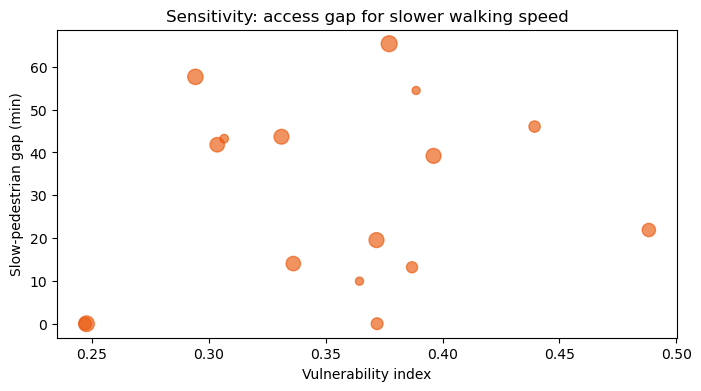

,zone_id,nearest_facility_min,scenario_min,slow_pedestrian_gap,vulnerability
10,Z11,61.92,17.71,65.40,0.38
7,Z08,55.73,55.73,57.67,0.29
15,Z16,53.19,0.00,54.48,0.39
12,Z13,46.44,46.44,46.05,0.44
1,Z02,44.54,44.54,43.68,0.33
3,Z04,44.18,44.18,43.23,0.31
11,Z12,43.05,43.05,41.81,0.30
14,Z15,40.96,40.96,39.21,0.40


In [12]:
slow_factor = 1.25
slow_gap = zones["nearest_facility_min"] * slow_factor - 12
zones["slow_pedestrian_gap"] = np.maximum(0, slow_gap)
sensitivity = zones[["zone_id", "nearest_facility_min", "scenario_min", "slow_pedestrian_gap", "vulnerability"]].copy()
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(sensitivity["vulnerability"], sensitivity["slow_pedestrian_gap"], s=zones["population"] / 35, alpha=0.65, color="#ea580c")
ax.set_xlabel("Vulnerability index")
ax.set_ylabel("Slow-pedestrian gap (min)")
ax.set_title("Sensitivity: access gap for slower walking speed")
fig.savefig(OUTPUTS / "slow_walker_sensitivity.png", dpi=170)
plt.show()
display(sensitivity.sort_values("slow_pedestrian_gap", ascending=False).head(8).round(2))

In [13]:
zones.drop(columns="geometry").to_csv(OUTPUTS / "zone_access_scenario_results.csv", index=False)
candidate_scores.to_csv(OUTPUTS / "candidate_site_scores.csv", index=False)
scenario.to_csv(OUTPUTS / "selected_facility_scenario.csv", index=False)
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- baseline_access_gap.png (39374 bytes)
- candidate_site_scores.csv (372 bytes)
- district_access_summary.csv (395 bytes)
- network_inventory.png (126039 bytes)
- scenario_access_improvement.png (35386 bytes)
- selected_facility_scenario.csv (247 bytes)
- slow_walker_sensitivity.png (51593 bytes)
- zone_access_scenario_results.csv (3226 bytes)


In [14]:
worst = zones.sort_values("gap_score", ascending=False).iloc[0]
display(Markdown(f'''## Case conclusion

The highest baseline gap is **{worst.zone_id}**, with {worst.nearest_facility_min:.1f} minutes to the nearest facility. The greedy three-site scenario selects nodes **{selected}**, reducing the citywide weighted gap score from **{baseline_gap:,.0f}** to **{scenario_gap:,.0f}**.
'''))

## Case conclusion

The highest baseline gap is **Z11**, with 61.9 minutes to the nearest facility. The greedy three-site scenario selects nodes **[18, 70, 41]**, reducing the citywide weighted gap score from **1,502,197** to **1,113,306**.
